<a href="https://colab.research.google.com/github/chayansaha2/Internship_Project_Task/blob/main/cognify_internship_project_task_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TASK-03**


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Dataset cognify.csv to Dataset cognify.csv



--- Task 3: Cuisine Classification ---
Classification Accuracy: 0.3906


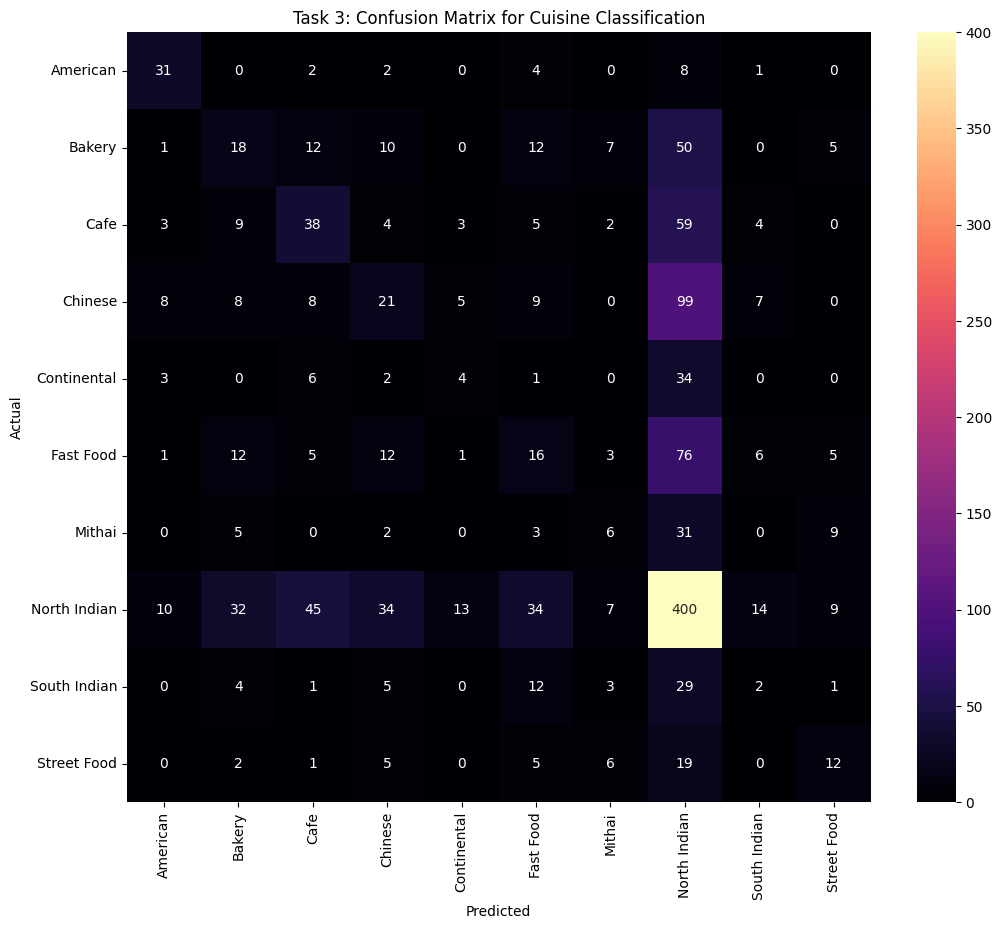

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

# Load the dataset
df = pd.read_csv('Dataset cognify.csv')

# --- DATA PREPROCESSING ---
# Handle missing values
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

# Encode categorical variables for Machine Learning
le = LabelEncoder()
df['Has Table booking'] = le.fit_transform(df['Has Table booking'])
df['Has Online delivery'] = le.fit_transform(df['Has Online delivery'])

# Prepare for Task 3: Simplify Cuisines to just the primary one
df['Primary Cuisine'] = df['Cuisines'].apply(lambda x: x.split(',')[0])


# TASK 3: Cuisine Classification

print("\n--- Task 3: Cuisine Classification ---")
# Focus on Top 10 cuisines for better visualization
top_10_cuisines = df['Primary Cuisine'].value_counts().nlargest(10).index
df_cls = df[df['Primary Cuisine'].isin(top_10_cuisines)].copy()

le_cls = LabelEncoder()
df_cls['Cuisine_Encoded'] = le_cls.fit_transform(df_cls['Primary Cuisine'])

X3 = df_cls[['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']]
y3 = df_cls['Cuisine_Encoded']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X3_train, y3_train)
y3_pred = classifier.predict(X3_test)

print(f"Classification Accuracy: {accuracy_score(y3_test, y3_pred):.4f}")

# Visualization 4: Confusion Matrix
cm = confusion_matrix(y3_test, y3_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le_cls.classes_, yticklabels=le_cls.classes_, cmap='magma')
plt.title('Task 3: Confusion Matrix for Cuisine Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()